# 1) Dataset Info

This section gives a basic overview of the dataset. The goal is to understand the structure, types of data, and any potential issues before diving deeper into analysis.

### Steps:
- Import necessary libraries
- Perform a basic inspection of the dataset:
  - View dataset shape (rows, columns)
  - Check data types (`dtypes`) of each column
  - Use `.info()` to see non-null counts and types
  - Use `.describe()` for summary statistics of numeric columns
  - List all column names
- Check for missing/null values
- Write a variable description for each column to explain what kind of data it holds
- Add a short conclusion/comment after each inspection step explaining what it reveals about the data


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
#Load the dataset 
df = pd.read_csv("FIFA24_PlayerStats.csv",encoding="ISO-8859-1")

#Dataset contains 41 columns and they can't be loaded all together so we use this method to load them all together
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
#Check the first 5 rows to get the basic idea about dataset:
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,att_position,interceptions,vision,composure,crossing,short_pass,long_pass,acceleration,stamina,strength,balance,sprint_speed,agility,jumping,heading,shot_power,finishing,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,73,72,68,30,65,30,50,33,64,49,41,55,86,40,52,43,51,64,54,30,31,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,58,62,70,69,70,64,54,60,63,63,64,87,81,42,67,65,65,54,60,64,68,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,16,27,65,17,20,49,48,14,35,18,46,38,68,41,48,36,60,17,51,14,20,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,69,71,64,48,66,29,70,44,58,53,35,73,82,56,63,57,80,67,32,24,33,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,16,28,50,10,12,38,34,11,23,20,38,28,64,24,31,34,27,13,48,4,6,9,10,16,5,61,59,62,64,64,$300.00


In [4]:
df.columns

Index(['player', 'country', 'height', 'weight', 'age', 'club', 'ball_control', 'dribbling', 'marking', 'slide_tackle', 'stand_tackle', 'aggression', 'reactions', 'att_position', 'interceptions', 'vision', 'composure', 'crossing', 'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength', 'balance', 'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'value'], dtype='object')

In [5]:
print(f'the dataset has {df.shape[0]} rows and {df.shape[1]} columns')

the dataset has 5682 rows and 41 columns


## Variable Descriptions

### Basic Info
- **player** — Name of the player.
- **country** — Nationality of the player.
- **height** — Player’s height in centimeters (cm).
- **weight** — Player’s weight in kilograms (kg).
- **age** — Player’s age in years.
- **club** — Club the player currently plays for.
- **value** — Market value of the player (e.g., $1.400.000 = 1.4 million USD).

---

### Technical & Offensive Attributes
- **ball_control** — Player’s ability to control the ball during possession.
- **dribbling** — Skill in maneuvering the ball while evading defenders.
- **crossing** — Accuracy and quality of crosses from wide areas.
- **short_pass** — Effectiveness in short-range passing.
- **long_pass** — Ability to deliver accurate long-range passes.
- **curve** — How much curve/spin the player can apply to the ball.
- **finishing** — Capability to convert shots into goals from close range.
- **volleys** — Skill in striking the ball while it’s in the air (before it touches the ground).
- **long_shots** — Proficiency in shooting accurately from long distances.
- **fk_acc** — Accuracy in taking direct free kicks.
- **penalties** — Effectiveness in taking penalty kicks.
- **shot_power** — Power behind the player’s shots.
- **att_position** — Ability to position themselves well in attacking situations.

---

### Defensive Attributes
- **marking** — Skill in closely marking and tracking opponents (contains NaNs).
- **slide_tackle** — Effectiveness in executing slide tackles.
- **stand_tackle** — Competence in standing tackles to dispossess players.
- **interceptions** — Ability to read the game and intercept passes.

---

### Physical & Athletic Attributes
- **acceleration** — How quickly a player reaches top speed.
- **sprint_speed** — Top running speed of the player.
- **agility** — Quickness and ease of movement/change of direction.
- **stamina** — Ability to maintain performance throughout the match.
- **strength** — Physical power and ability to hold off opponents.
- **balance** — Stability and control while in motion or under pressure.
- **jumping** — Vertical leap height.
- **heading** — Accuracy and power in heading the ball.

---

### Mental Attributes
- **reactions** — Speed at which the player responds to in-game events.
- **vision** — Ability to spot and execute key passes.
- **composure** — Performance under pressure and ability to stay calm.
- **aggression** — Level of assertiveness and physical engagement.

---

### Goalkeeper-Specific Attributes
*(These are mostly relevant for goalkeepers; will be low or zero for outfield players)*
- **gk_positioning** — Ability to position correctly in goal during shots.
- **gk_diving** — Diving skill to save shots.
- **gk_handling** — Ability to catch or hold on to the ball.
- **gk_kicking** — Accuracy and power in goal kicks or distribution.
- **gk_reflexes** — Quick reaction to make close-range or sudden saves.

In [6]:
#Basic Stats of the dataset
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,att_position,interceptions,vision,composure,crossing,short_pass,long_pass,acceleration,stamina,strength,balance,sprint_speed,agility,jumping,heading,shot_power,finishing,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,0.0,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.00000,5682.000000,5682.000000,5682.000000
mean,181.670539,75.282295,26.316262,58.912179,56.128476,NaN,46.728441,48.820838,56.324006,61.959345,50.724921,47.389124,54.465681,58.620908,49.790391,59.333333,53.910771,64.754664,63.377332,65.381204,64.070398,64.958993,63.780535,65.085005,52.245336,58.182682,46.354277,47.164203,48.099789,43.299542,48.174938,42.931890,16.187610,16.43805,16.191834,16.071982,16.570222
std,6.829238,6.998971,4.729967,16.567068,18.772075,NaN,20.519430,20.975966,16.846410,8.893309,19.780636,20.451327,13.705286,12.024102,17.898054,14.326017,14.601361,15.298600,16.105897,12.624053,14.495444,15.114044,14.857875,12.274525,17.359459,12.971923,19.822642,19.463368,18.086672,17.086473,15.781737,17.912619,17.146572,17.63526,16.993154,16.808674,17.942154
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,3.000000,3.000000,10.000000,13.000000,6.000000,11.000000,9.000000,12.000000,14.000000,25.000000,20.000000,13.000000,21.000000,23.000000,6.000000,20.000000,4.000000,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.00000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,40.000000,28.000000,45.000000,52.000000,39.000000,55.000000,46.000000,57.000000,56.000000,58.000000,56.000000,57.000000,56.000000,57.000000,45.000000,49.000000,31.000000,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.00000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,56.000000,54.000000,56.000000,60.000000,54.000000,63.000000,57.000000,68.000000,66.000000,66.500000,66.000000,68.000000,66.000000,66.000000,55.000000,59.000000,51.000000,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.00000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,65.000000,64.000000,65.000000,67.000000,63.000000,68.000000,64.000000,75.000000,74.000000,74.000000,74.000000,75.000000,74.000000,73.000000,64.000000,68.000000,62.000000,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.00000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,93.000000,89.000000,94.000000,96.000000,94.000000,93.000000,93.000000,97.000000,95.000000,96.000000,95.000000,97.000000,93.000000,95.000000,93.000000,94.000000,94.000000,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.00000,87.000000,90.000000,89.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

In [8]:
#Check for datatypes  
df.dtypes

player             object
country            object
height              int64
weight              int64
age                 int64
club               object
ball_control        int64
dribbling           int64
marking           float64
slide_tackle        int64
stand_tackle        int64
aggression          int64
reactions           int64
att_position        int64
interceptions       int64
vision              int64
composure           int64
crossing            int64
short_pass          int64
long_pass           int64
acceleration        int64
stamina             int64
strength            int64
balance             int64
sprint_speed        int64
agility             int64
jumping             int64
heading             int64
shot_power          int64
finishing           int64
long_shots          int64
curve               int64
fk_acc              int64
penalties           int64
volleys             int64
gk_positioning      int64
gk_diving           int64
gk_handling         int64
gk_kicking  

In [9]:
#Check for Null Values + The percentage of Null Values 
df.isnull().sum()

player               0
country              0
height               0
weight               0
age                  0
club                 0
ball_control         0
dribbling            0
marking           5682
slide_tackle         0
stand_tackle         0
aggression           0
reactions            0
att_position         0
interceptions        0
vision               0
composure            0
crossing             0
short_pass           0
long_pass            0
acceleration         0
stamina              0
strength             0
balance              0
sprint_speed         0
agility              0
jumping              0
heading              0
shot_power           0
finishing            0
long_shots           0
curve                0
fk_acc               0
penalties            0
volleys              0
gk_positioning       0
gk_diving            0
gk_handling          0
gk_kicking           0
gk_reflexes          0
value                0
dtype: int64

we'll have to just drop or engineer the **marking** column other columns are free of null values

In [10]:
print("% of Null values in marking column")
(df['marking'].isnull().mean()*100)

% of Null values in marking column


100.0

### Get the numerical and categorical columns 


In [11]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical Columns {categorical_cols}\n\nNumerical columns {numerical_cols}')

Categorical Columns ['player', 'country', 'club', 'value']

Numerical columns ['height', 'weight', 'age', 'ball_control', 'dribbling', 'marking', 'slide_tackle', 'stand_tackle', 'aggression', 'reactions', 'att_position', 'interceptions', 'vision', 'composure', 'crossing', 'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength', 'balance', 'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes']


these cols will be later used for univariate analysis

# Univariate Analysis

In this section, we analyze each feature individually to understand its distribution, frequency, and overall behavior. Univariate analysis is a crucial step in EDA, as it helps us identify trends, outliers, and potential data quality issues.

We categorize features into two types for this analysis:

### 1. Categorical Features
- These are non-numeric columns such as player name, country, or club.
- We analyze them using visualizations like `countplot` or `barplot` to see how frequently each category appears.

### 2. Numerical Features
- These are continuous or discrete numeric values such as age, height, weight, or skill ratings.
- We use plots like `histplot`, `boxplot`, and basic statistical summaries to understand their distribution, range, and any potential outliers.

This step helps build a deeper understanding of each variable before we explore relationships between them in bivariate analysis.ate analysis.


### Categorical Univariate:
- we'll only plot top 20's for each categorical column because it'll be less insightful if we draw all 5000 rows

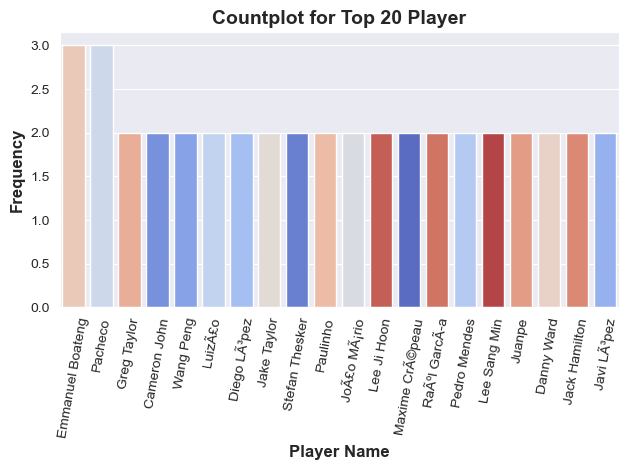

In [12]:
#Countplot for top20 players 
sns.set_style("darkgrid")
top_20 = df['player'].value_counts().nlargest(20).index
filtered_df = df[df['player'].isin(top_20)]
sns.countplot(data=filtered_df, x='player', order=top_20,legend=False,hue='player',palette='coolwarm')
plt.xlabel('Player Name',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Player',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

**Emmanuel Boateng** and **Pacheco** appear multiple times in the dataset, suggesting either duplicate entries or multiple records due to club transfers or position variations. The rest of the player names show a consistent, non-repetitive distribution, indicating unique entries.

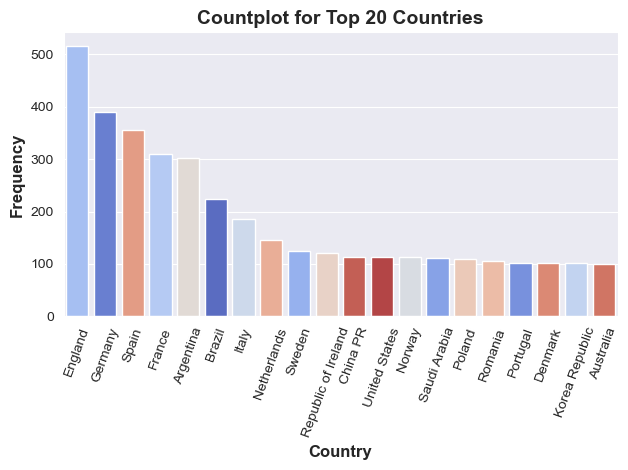

In [13]:
#Countplot for top20 Countries 
sns.set_style("darkgrid")
top_20 = df['country'].value_counts().nlargest(20).index
filtered_df = df[df['country'].isin(top_20)]
sns.countplot(data=filtered_df, x='country', order=top_20,legend=False,hue='country',palette='coolwarm')
plt.xlabel('Country',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Countries',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

**England** tops the chart as the country with the highest number of players in the dataset, indicating a strong representation of English talent in FIFA24. It is followed closely by **Germany** and **Spain**, both of which also contribute significantly to the global player pool.

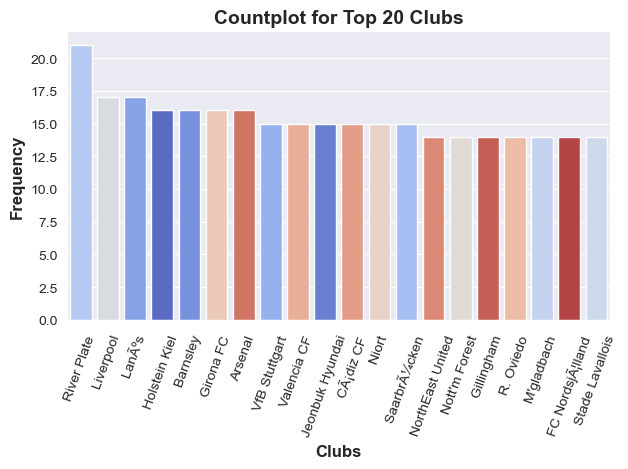

In [14]:
#Countplot for top20 Clubs 
sns.set_style("darkgrid")
top_20 = df['club'].value_counts().nlargest(20).index
filtered_df = df[df['club'].isin(top_20)]
sns.countplot(data=filtered_df, x='club', order=top_20,legend=False,hue='club',palette='coolwarm')
plt.xlabel('Clubs',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Clubs',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

River plate tops the chart followed by Liverpool and LanĀ°S football club which is basically (Lanus) 

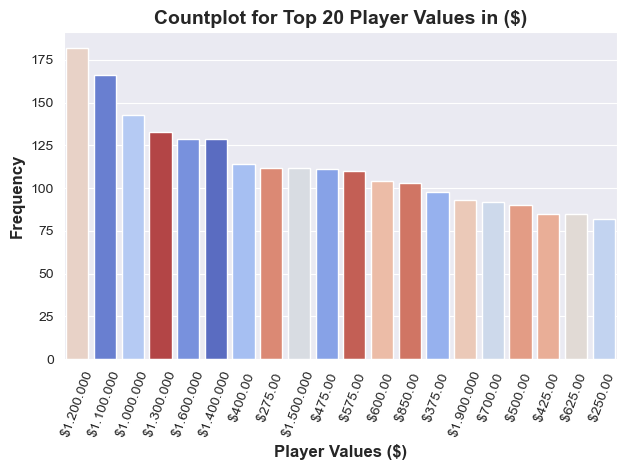

In [15]:
#Countplot for top20 Clubs 
sns.set_style("darkgrid")
top_20 = df['value'].value_counts().nlargest(20).index
filtered_df = df[df['value'].isin(top_20)]
sns.countplot(data=filtered_df, x='value', order=top_20,legend=False,hue='value',palette='coolwarm')
plt.xlabel('Player Values ($)',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Player Values in ($)',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

highest paid athlete is **$1.200.000**

## Numerical Univariate Analysis

In this stage, we explored the distribution of numerical features in the dataset. Rather than visualizing all numerical columns, we selectively analyzed 6–7 key attributes to keep the analysis focused, meaningful, and easy to interpret.

The selected features were chosen based on their relevance to player performance, physical attributes, and market value. These include:

- Age
- Height
- Ball Control
- Sprint Speed
- Strength
- Goalkeeper Reflexes

Histograms were used to visualize the distribution of each selected feature. Key takeaways and observations were noted to better understand player demographics and characteristics. The remaining numerical features were scanned during initial exploration but omitted from visual plots to maintain readability and avoid unnecessary repetition.


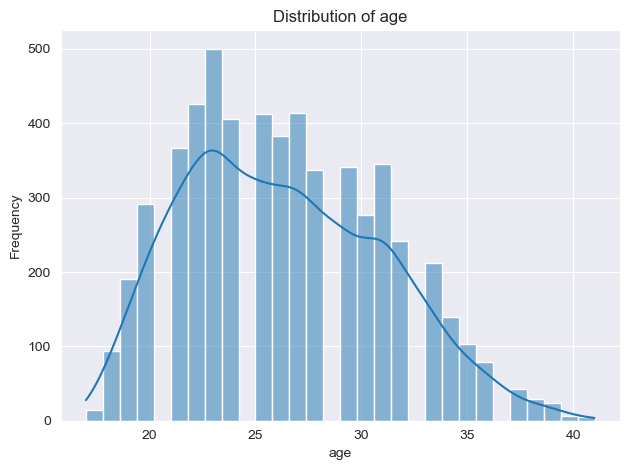

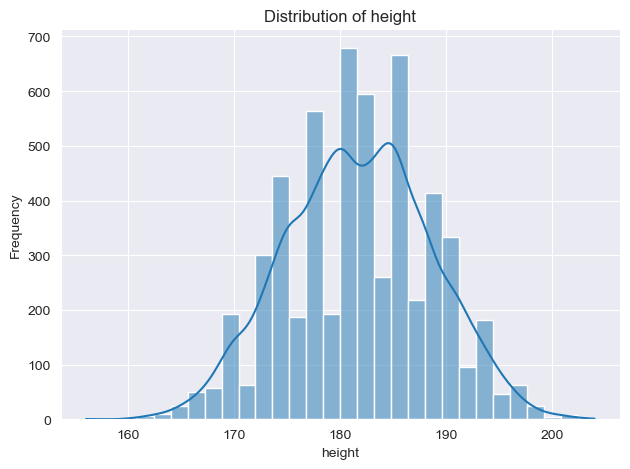

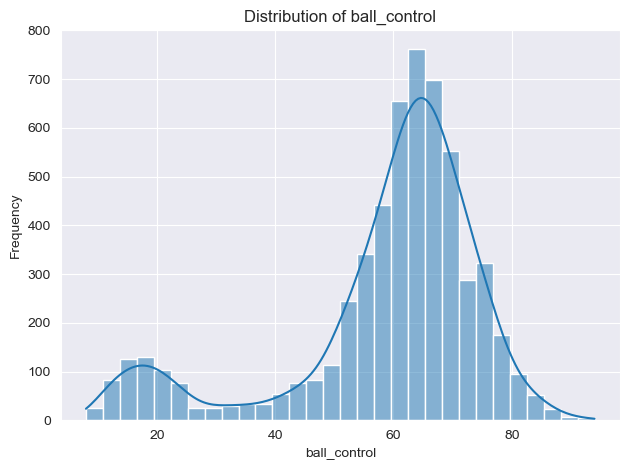

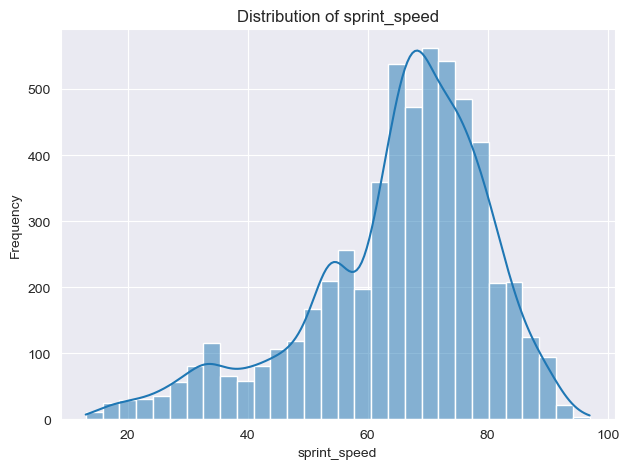

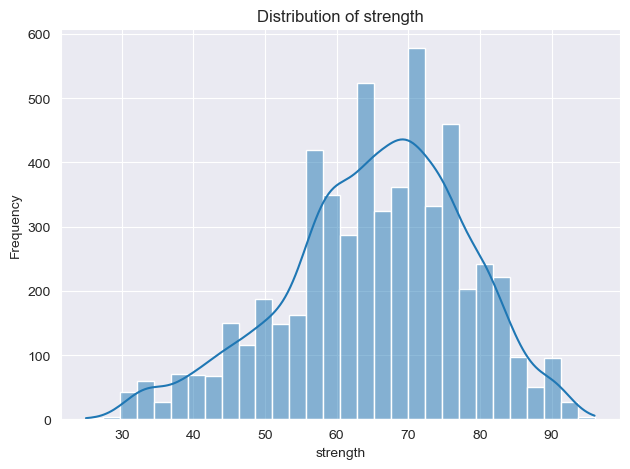

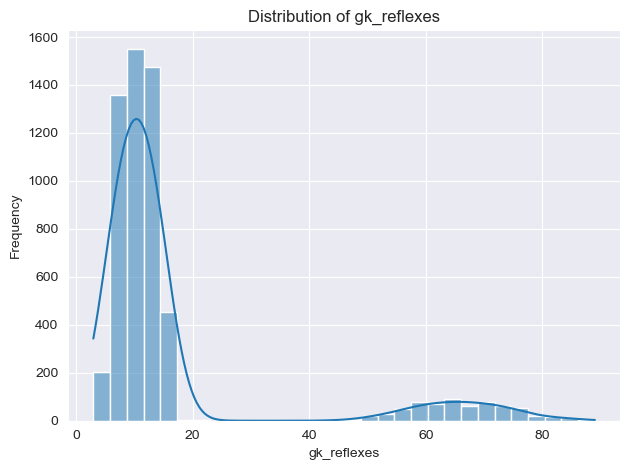

In [20]:
def plot_numerical(feature):
    sns.set_style("darkgrid")
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

features_to_plot = ['age', 'height', 'ball_control', 'sprint_speed', 'strength', 'gk_reflexes']

for col in features_to_plot:
    plot_numerical(col)

> **Note:**  
> This is the Univariate Analysis stage where we are exploring the raw dataset. The focus here is to understand the distribution, frequency, and behavior of individual features.  
> 
> Data cleaning steps such as handling missing values, correcting inconsistencies (e.g., encoding issues), and feature transformation will be performed in the next phase.  
> 
> The purpose of this stage is purely to "get to know the data" before any modifications are made.
